# Weighted turbine power

This notebook shows the high-level API for wind farms where turbines do not all have the same nominal power. Pass `turbine_power` to `WindFarmNetwork`; cable capacities are interpreted in the same units. OptiWindNet converts the powers to integer quanta internally, and the MILP router uses those weighted loads when selecting feeders and cables.

Weighted turbine power is currently a `MILPRouter` feature. The examples below also compare the same layout with and without power weighting.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

from optiwindnet.api import MILPRouter, WindFarmNetwork

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

## Define the layout and powers

In [3]:
turbinesC = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.4],
        [2.0, 0.0],
        [0.3, 1.2],
        [1.3, 1.6],
        [2.4, 1.1],
    ]
)
substationsC = np.array([[1.2, -1.0]])

# Cable capacities and turbine powers use the same nominal units.
cables = [(2, 1.0), (3, 1.3), (4, 1.6)]
turbine_power = [1.0, 1.0, 1.5, 1.5, 2.0, 2.0]

In [4]:
wfn = WindFarmNetwork(
    cables=cables,
    turbinesC=turbinesC,
    substationsC=substationsC,
    turbine_power=turbine_power,
    turbine_power_decimals=1,
)

print('Power decimal places preserved: 1')
print(f'Power scale: {wfn.power_scale}')
print('Nominal turbine power:', wfn.turbine_power)
print(
    'Integer power quanta:',
    [wfn.L.nodes[t]['power'] for t in range(len(turbine_power))],
)
print(f'Total nominal power: {sum(wfn.turbine_power):.1f}')

Power decimal places preserved: 1
Power scale: 2
Nominal turbine power: [1.0, 1.0, 1.5, 1.5, 2.0, 2.0]
Integer power quanta: [2, 2, 3, 3, 4, 4]
Total nominal power: 9.0


## Rounding and integer power scale

`turbine_power_decimals` defaults to `1`. Increase it when smaller differences in turbine power should be preserved. The resulting `power_scale` is the factor between nominal power units and the integer quanta used internally by the optimization model.

In [5]:
rounding_power = [1.0, 1.25, 1.0, 1.25, 1.5, 1.75]
rounding_examples = []

for decimals in [1, 2]:
    rounded_wfn = WindFarmNetwork(
        cables=cables,
        turbinesC=turbinesC,
        substationsC=substationsC,
        turbine_power=rounding_power,
        turbine_power_decimals=decimals,
    )
    rounding_examples.append(
        {
            'turbine_power_decimals': decimals,
            'rounded_power': rounded_wfn.turbine_power,
            'power_scale': rounded_wfn.power_scale,
            'power_quanta': [
                rounded_wfn.L.nodes[t]['power'] for t in range(len(rounding_power))
            ],
        }
    )

rounding_examples

[{'turbine_power_decimals': 1,
  'rounded_power': [1.0, 1.3, 1.0, 1.3, 1.5, 1.8],
  'power_scale': 10,
  'power_quanta': [10, 13, 10, 13, 15, 18]},
 {'turbine_power_decimals': 2,
  'rounded_power': [1.0, 1.25, 1.0, 1.25, 1.5, 1.75],
  'power_scale': 4,
  'power_quanta': [4, 5, 4, 5, 6, 7]}]

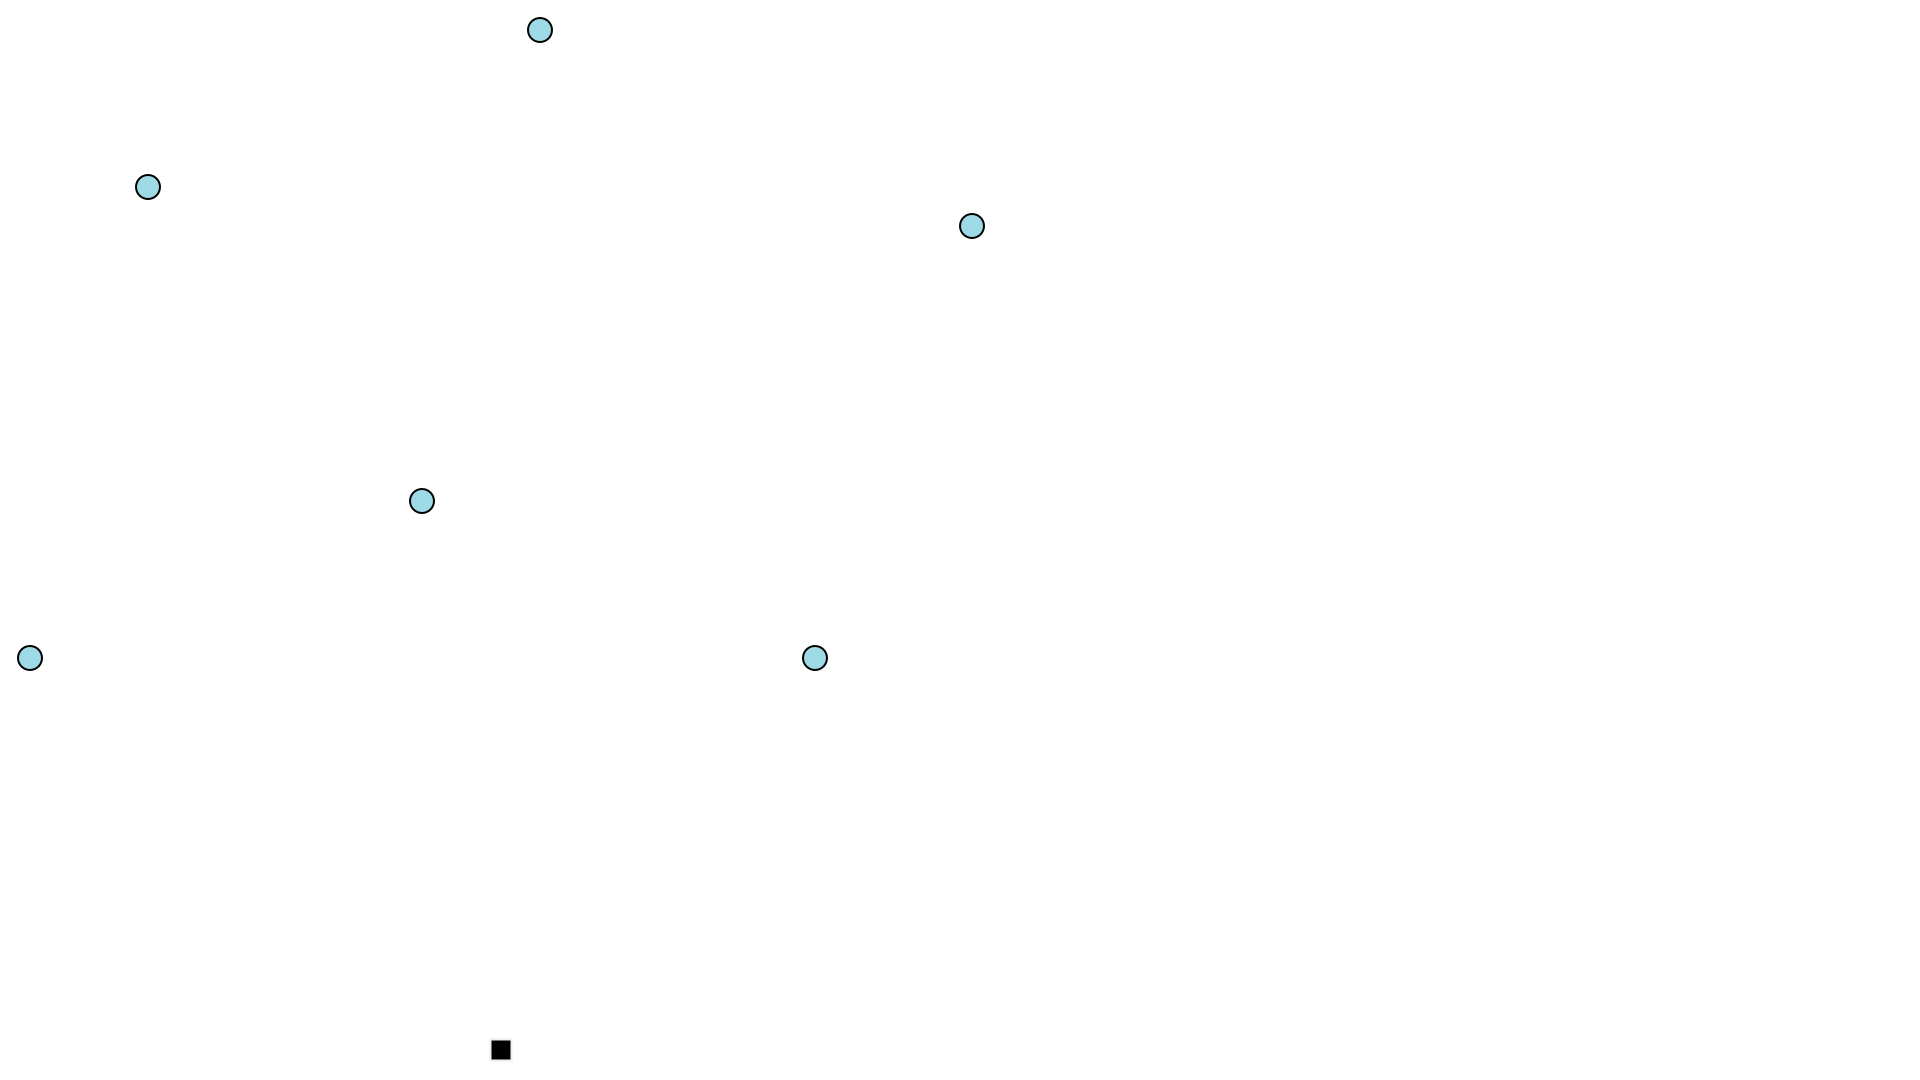

In [6]:
wfn.plot_location()

## Optimize with a MILP router

Use a MILP router for non-uniform turbine power. Heuristic routers such as `EWRouter` and `HGSRouter` currently assume unit-power turbines and reject non-uniform `turbine_power`.

This notebook uses `ortools.highs` as the reference backend. Other MILP backends such as `highs`, `scip`, `gurobi`, or `cplex` can also be used when installed. Support and performance for `ortools.cp_sat` depends on the installed OR-Tools stack, so it is not used as the reference path here.

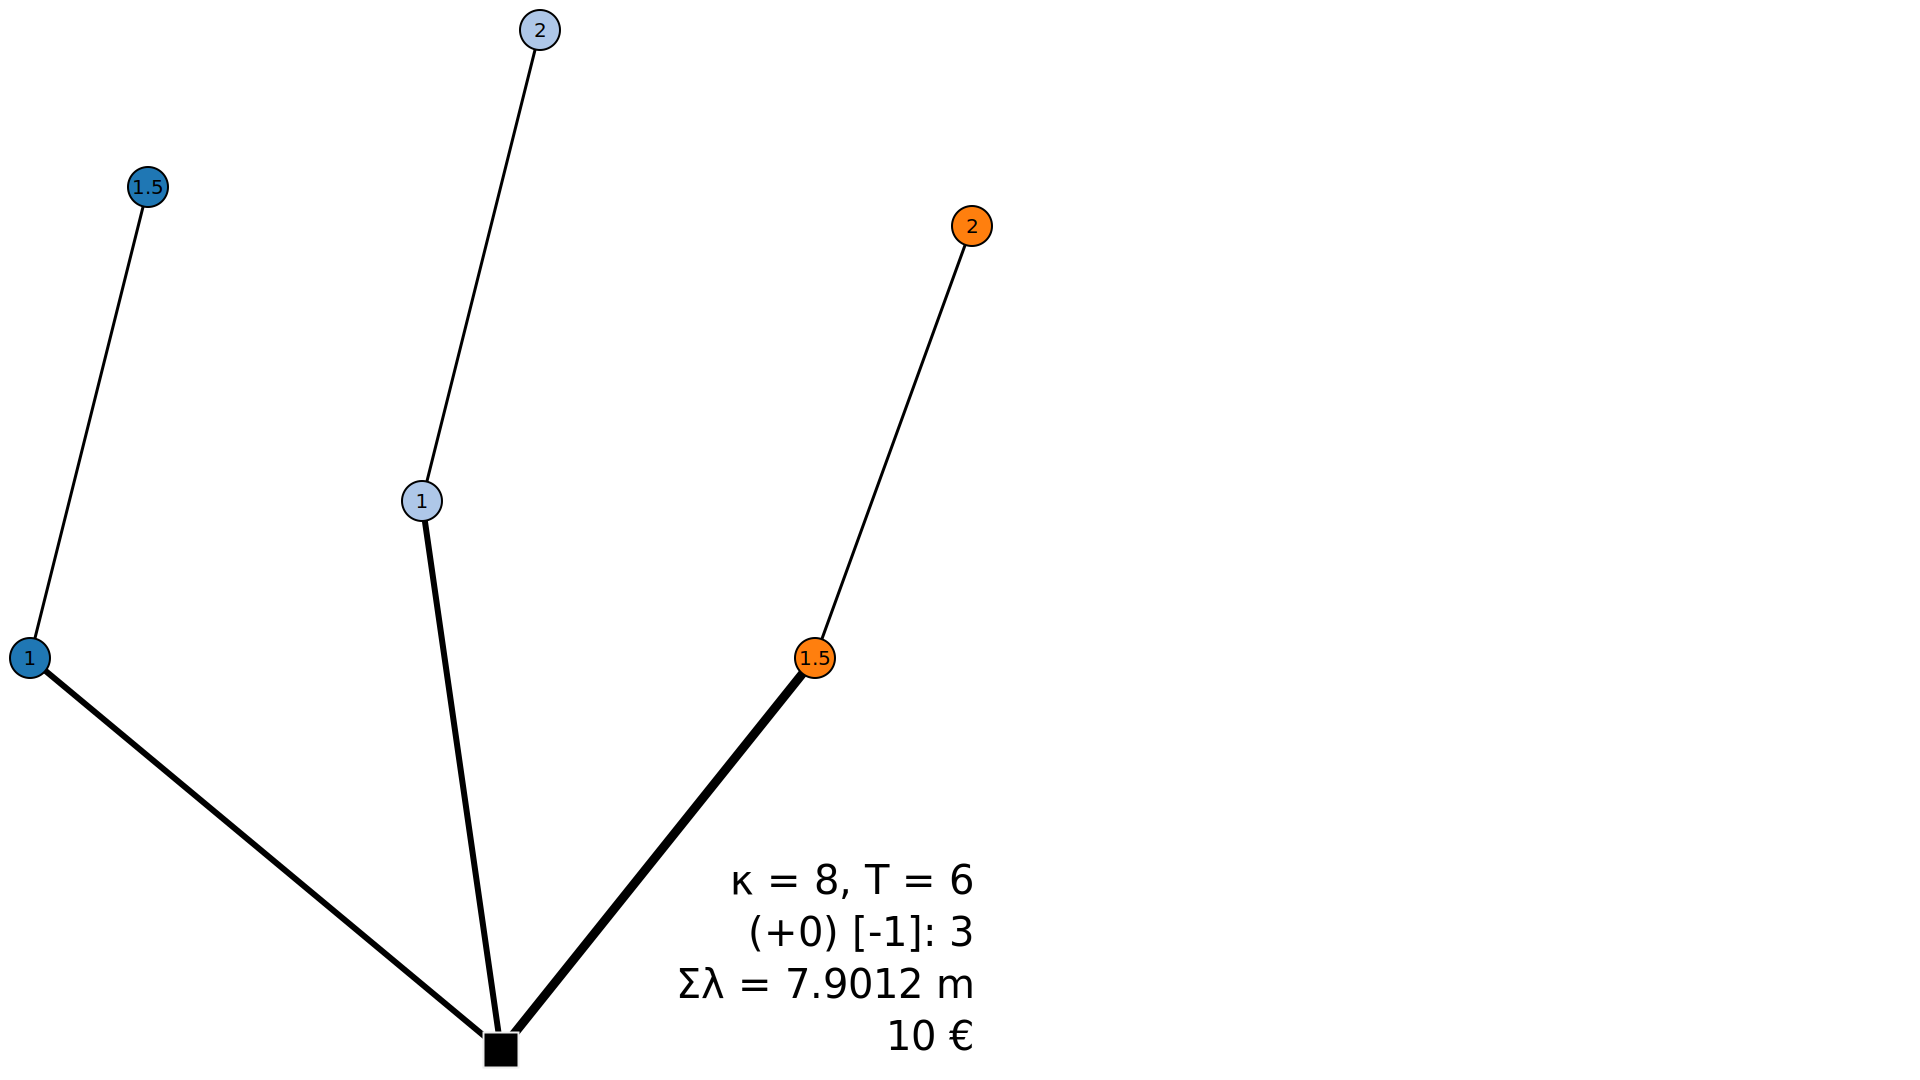

In [7]:
solver_name = 'ortools.highs'
router = MILPRouter(solver_name=solver_name, time_limit=5, mip_gap=0.01)
wfn.optimize(router=router)


def add_nominal_power_tags(wfn_case):
    powers = wfn_case.turbine_power or [1.0] * wfn_case.L.graph['T']
    for turbine, power in enumerate(powers):
        wfn_case.G.nodes[turbine]['power_nominal'] = f'{power:g}'


add_nominal_power_tags(wfn)
wfn.plot(node_tag='power_nominal')

In [8]:
print('Terse links:', wfn.terse_links())
print(f'Network cost: {wfn.cost():.3f}')
print(f'Network length: {wfn.length():.3f}')

wfn.solution_info()

Terse links: [-1 -1 -1  0  1  2]
Network cost: 9.562
Network length: 7.901


{'router': 'MILPRouter',
 'capacity': 4,
 'solver_name': 'ortools.highs',
 'mip_gap': 0.01,
 'time_limit': 5,
 'topology': <Topology.BRANCHED: 'branched'>,
 'feeder_route': <FeederRoute.SEGMENTED: 'segmented'>,
 'feeder_limit': <FeederLimit.UNLIMITED: 'unlimited'>,
 'balanced': False,
 'runtime': 0.013418,
 'bound': 7.901221711483554,
 'objective': 7.901221711483554,
 'relgap': 0.0,
 'termination': 'OPTIMAL'}

## Compare uniform and weighted power

The comparison below uses the same coordinates, cable catalogue, solver, and solver settings. The uniform case uses unit turbine power; the weighted case uses the non-uniform powers defined above.

In [9]:
def solve_network(turbine_power=None):
    wfn_case = WindFarmNetwork(
        cables=cables,
        turbinesC=turbinesC,
        substationsC=substationsC,
        turbine_power=turbine_power,
    )
    router = MILPRouter(solver_name=solver_name, time_limit=5, mip_gap=0.01)
    wfn_case.optimize(router=router)
    return wfn_case


def nominal_powers(wfn_case):
    if wfn_case.turbine_power is not None:
        return wfn_case.turbine_power
    return [1.0] * wfn_case.L.graph['T']


def nominal_edge_loads(wfn_case):
    return [data['load'] / wfn_case.power_scale for *_, data in wfn_case.G.edges(data=True)]


def summarize_network(label, wfn_case):
    return {
        'case': label,
        'power_scale': wfn_case.power_scale,
        'total_power': round(sum(nominal_powers(wfn_case)), 3),
        'feeder_count': sum(1 for u, v in wfn_case.G.edges if u < 0 or v < 0),
        'max_edge_load': round(max(nominal_edge_loads(wfn_case)), 3),
        'cost': round(wfn_case.cost(), 3),
        'length': round(wfn_case.length(), 3),
        'terse_links': wfn_case.terse_links().tolist(),
    }


uniform_power = [1.0] * len(turbine_power)
uniform_wfn = solve_network(uniform_power)
weighted_wfn = wfn

comparison = [
    summarize_network('uniform turbines', uniform_wfn),
    summarize_network('weighted turbines', weighted_wfn),
]
comparison

[{'case': 'uniform turbines',
  'power_scale': 1,
  'total_power': 6.0,
  'feeder_count': 2,
  'max_edge_load': 4.0,
  'cost': 7.931,
  'length': 7.082,
  'terse_links': [1, -1, -1, 1, 3, 2]},
 {'case': 'weighted turbines',
  'power_scale': 2,
  'total_power': 9.0,
  'feeder_count': 3,
  'max_edge_load': 3.5,
  'cost': 9.562,
  'length': 7.901,
  'terse_links': [-1, -1, -1, 0, 1, 2]}]

## Visual comparison

The two panels below show the solved networks directly. Node labels show nominal turbine power using `node_tag='power_nominal'`; the real `power` graph attribute is still kept in scaled integer quanta for the solver. The weighted case uses one extra feeder and a different topology because the optimizer is routing power load, not just turbine count.

In [10]:
def svg_panel(title, wfn_case):
    add_nominal_power_tags(wfn_case)
    svg = wfn_case.plot(node_tag='power_nominal').data.replace(
        '<svg ', '<svg style="width: 100%; height: auto;" ', 1
    )
    return f'''
    <section style="flex: 1; min-width: 320px;">
      <h3 style="font-family: sans-serif; margin: 0 0 0.25rem;">{title}</h3>
      {svg}
    </section>
    '''


display(
    HTML(
        f'''
        <div style="display: flex; flex-wrap: wrap; gap: 1rem; align-items: flex-start;">
          {svg_panel('Uniform turbines', uniform_wfn)}
          {svg_panel('Weighted turbines', weighted_wfn)}
        </div>
        '''
    )
)

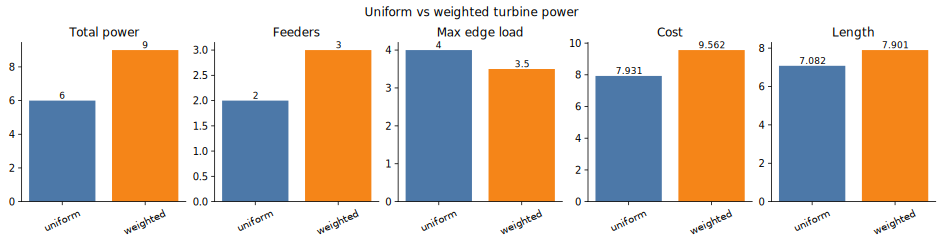

In [11]:
metrics = [
    ('total_power', 'Total power'),
    ('feeder_count', 'Feeders'),
    ('max_edge_load', 'Max edge load'),
    ('cost', 'Cost'),
    ('length', 'Length'),
]
colors = ['#4c78a8', '#f58518']

fig, axes = plt.subplots(1, len(metrics), figsize=(13, 3), constrained_layout=True)
for ax, (metric, label) in zip(axes, metrics):
    values = [case[metric] for case in comparison]
    ax.bar(['uniform', 'weighted'], values, color=colors)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=25)
    ax.spines[['top', 'right']].set_visible(False)
    for index, value in enumerate(values):
        ax.text(index, value, f'{value:g}', ha='center', va='bottom', fontsize=9)

_ = fig.suptitle('Uniform vs weighted turbine power', y=1.08)
plt.show()

For the weighted solution, edge loads are stored in integer quanta. Divide by `power_scale` to read them in the nominal power units used above.

In [12]:
edge_loads = [
    {
        'u': u,
        'v': v,
        'load_quanta': data['load'],
        'load_nominal': data['load'] / weighted_wfn.power_scale,
        'cable_index': data.get('cable'),
    }
    for u, v, data in weighted_wfn.G.edges(data=True)
]
edge_loads

[{'u': -1, 'v': 1, 'load_quanta': 6, 'load_nominal': 3.0, 'cable_index': 1},
 {'u': -1, 'v': 0, 'load_quanta': 5, 'load_nominal': 2.5, 'cable_index': 1},
 {'u': -1, 'v': 2, 'load_quanta': 7, 'load_nominal': 3.5, 'cable_index': 2},
 {'u': 3, 'v': 0, 'load_quanta': 3, 'load_nominal': 1.5, 'cable_index': 0},
 {'u': 4, 'v': 1, 'load_quanta': 4, 'load_nominal': 2.0, 'cable_index': 0},
 {'u': 5, 'v': 2, 'load_quanta': 4, 'load_nominal': 2.0, 'cable_index': 0}]